# Tarea 1 - Deep Learning

Integrantes:
- Estrella Bustos
- Matias Herrera
- Vicente Leiva



# Introducción

En esta tarea se desarrollarán dos actividades enfocadas en el diseño, construcción y validación de una Deep Neural Network (DNN). En la primera actividad se implementará un modelo DNN, ejecutando las fases de entrenamiento, validación y prueba. En la segunda, se utilizará una herramienta de búsqueda automatizada de arquitectura, con el objetivo de comparar el desempeño de ambos enfoques y analizar cuál se ajusta mejor al problema planteado.

# Generación de Dataset

Se generó un dataset enfocado en combates Pokémon que cumple con el requerimiento mínimo de volumen al procesar 2.100.000 registros y 30 características. Cada registro representa una batalla única entre dos especies, utilizando como características principales las estadísticas de ambos combatientes (vida, ataque, defensa, velocidad, etc.), sus tipos elementales en formato numérico y sus respectivos niveles. La variable objetivo es binaria y define el resultado del enfrentamiento (1 si el primer Pokémon gana, 0 si pierde).

Para su construcción, se extrae la información de 850 especies directamente desde la PokeAPI. Luego, se simulan los combates de forma determinista mediante una fórmula matemática de daño, procesando la información en bloques, reduciendo el peso de las variables numéricas y exportando el conjunto final en formato Parquet (binario comprimido), proporcionando los datos para el entrenamiento del modelo.

In [ ]:
import os
import gc
import requests
import numpy as np
import pandas as pd
from tqdm.auto import tqdm

# Conexión con PokeAPI

print("conectando a PokeAPI...")

TYPE_MAP = {
    'normal': 0, 'fire': 1, 'water': 2, 'electric': 3, 'grass': 4,
    'ice': 5, 'fighting': 6, 'poison': 7, 'ground': 8, 'flying': 9,
    'psychic': 10, 'bug': 11, 'rock': 12, 'ghost': 13, 'dragon': 14,
    'dark': 15, 'steel': 16, 'fairy': 17
}

def fetch_pokemon_from_api(limit=850):
    url = f"https://pokeapi.co/api/v2/pokemon?limit={limit}"
    response = requests.get(url).json()
    urls = [res['url'] for res in response['results']]

    pokemon_data = []
    for p_url in tqdm(urls, desc="Descargando Pokémon"):
        try:
            data = requests.get(p_url).json()

            stats = {s['stat']['name']: s['base_stat'] for s in data['stats']}

            types = data['types']
            type1 = types[0]['type']['name']
            type2 = types[1]['type']['name'] if len(types) > 1 else None

            row = {
                "id": data['id'],
                "name": data['name'],
                "hp": stats.get('hp', 0),
                "attack": stats.get('attack', 0),
                "defense": stats.get('defense', 0),
                "sp_attack": stats.get('special-attack', 0),
                "sp_defense": stats.get('special-defense', 0),
                "speed": stats.get('speed', 0),
                "type1_idx": TYPE_MAP.get(type1, 0),
                "type2_idx": TYPE_MAP.get(type2, float('nan')) if type2 else float('nan'),
                "is_dual_type": 1 if type2 else 0,
                "weight": data['weight'] / 10.0,
                "height": data['height'] / 10.0,
                "base_exp": data.get('base_experience', 50) or 50,
                "is_legendary": 0, "is_mythical": 0, "generation": 1, "capture_rate": 45
            }
            pokemon_data.append(row)
        except Exception as e:
            continue

    return pd.DataFrame(pokemon_data)

df_pokemon = fetch_pokemon_from_api(limit=850)
df_pokemon["total_stats"] = df_pokemon[["hp", "attack", "defense", "sp_attack", "sp_defense", "speed"]].sum(axis=1)
print(f"¡Se descargaron {len(df_pokemon)} Pokémon correctamente!")

type_matrix = np.ones((18, 18))

def get_type_effectiveness(atk_type1, atk_type2, def_type1, def_type2):
    eff = 1.0
    if pd.notna(atk_type1) and pd.notna(def_type1):
        eff *= type_matrix[int(atk_type1)][int(def_type1)]
    if pd.notna(atk_type1) and pd.notna(def_type2):
        eff *= type_matrix[int(atk_type1)][int(def_type2)]
    return eff

# Generación del dataset

LEVELS = (50, 75, 100)
TARGET_ROWS = 2_100_000
CHUNK_SIZE = 250_000
OUTPUT_DIR = "/content/pokemon_dataset"
MOVE_POWER = 80
os.makedirs(OUTPUT_DIR, exist_ok=True)

pokemon_cols = [
    "id", "hp", "attack", "defense", "sp_attack", "sp_defense", "speed",
    "total_stats", "type1_idx", "type2_idx", "is_legendary", "is_mythical",
    "generation", "weight", "height", "capture_rate", "base_exp", "is_dual_type"
]
pokemon_list = df_pokemon[pokemon_cols].to_dict(orient="records")

def calc_hp(base_hp, level, iv=15):
    return int(((2 * base_hp + iv) * level) / 100) + level + 10

def calc_stat(base, level, iv=15, nature=1.0):
    return int((int(((2 * base + iv) * level) / 100) + 5) * nature)

def simulate_row(p1, p2, level_p1, level_p2, nature_p1=1.0, nature_p2=1.0, move_power=MOVE_POWER):
    hp1 = calc_hp(p1["hp"], level_p1)
    hp2 = calc_hp(p2["hp"], level_p2)
    atk1 = calc_stat(p1["attack"], level_p1, nature=nature_p1)
    def1 = calc_stat(p1["defense"], level_p1, nature=nature_p1)
    spa1 = calc_stat(p1["sp_attack"], level_p1, nature=nature_p1)
    spd1 = calc_stat(p1["sp_defense"], level_p1, nature=nature_p1)
    spe1 = calc_stat(p1["speed"], level_p1, nature=nature_p1)

    atk2 = calc_stat(p2["attack"], level_p2, nature=nature_p2)
    def2 = calc_stat(p2["defense"], level_p2, nature=nature_p2)
    spa2 = calc_stat(p2["sp_attack"], level_p2, nature=nature_p2)
    spd2 = calc_stat(p2["sp_defense"], level_p2, nature=nature_p2)
    spe2 = calc_stat(p2["speed"], level_p2, nature=nature_p2)

    eff_1_vs_2 = get_type_effectiveness(p1["type1_idx"], p1["type2_idx"], p2["type1_idx"], p2["type2_idx"])
    eff_2_vs_1 = get_type_effectiveness(p2["type1_idx"], p2["type2_idx"], p1["type1_idx"], p1["type2_idx"])

    dpt_phys_1 = ((((2 * level_p1 / 5 + 2) * move_power * atk1 / max(def2, 1)) / 50) + 2) * eff_1_vs_2 * 1.5
    dpt_spec_1 = ((((2 * level_p1 / 5 + 2) * move_power * spa1 / max(spd2, 1)) / 50) + 2) * eff_1_vs_2 * 1.5
    dpt1 = dpt_phys_1 if dpt_phys_1 > dpt_spec_1 else dpt_spec_1

    dpt_phys_2 = ((((2 * level_p2 / 5 + 2) * move_power * atk2 / max(def1, 1)) / 50) + 2) * eff_2_vs_1 * 1.5
    dpt_spec_2 = ((((2 * level_p2 / 5 + 2) * move_power * spa2 / max(spd1, 1)) / 50) + 2) * eff_2_vs_1 * 1.5
    dpt2 = dpt_phys_2 if dpt_phys_2 > dpt_spec_2 else dpt_spec_2

    kot1 = hp2 / max(dpt1, 1e-9)
    kot2 = hp1 / max(dpt2, 1e-9)
    p1_faster = int(spe1 > spe2)

    if kot1 < kot2:
        winner = 1
    elif kot2 < kot1:
        winner = 0
    elif spe1 > spe2:
        winner = 1
    elif spe2 > spe1:
        winner = 0
    else:
        winner = int(p1["total_stats"] >= p2["total_stats"])

    return {
        "p1_id": p1["id"], "p1_hp_base": p1["hp"], "p1_attack": p1["attack"], "p1_defense": p1["defense"],
        "p1_sp_attack": p1["sp_attack"], "p1_sp_defense": p1["sp_defense"], "p1_speed": p1["speed"],
        "p1_total_stats": p1["total_stats"], "p1_type1_idx": p1["type1_idx"], "p1_type2_idx": p1["type2_idx"],
        "p1_is_dual_type": p1["is_dual_type"], "p1_level": level_p1,
        "p2_id": p2["id"], "p2_hp_base": p2["hp"], "p2_attack": p2["attack"], "p2_defense": p2["defense"],
        "p2_sp_attack": p2["sp_attack"], "p2_sp_defense": p2["sp_defense"], "p2_speed": p2["speed"],
        "p2_total_stats": p2["total_stats"], "p2_type1_idx": p2["type1_idx"], "p2_type2_idx": p2["type2_idx"],
        "p2_is_dual_type": p2["is_dual_type"], "p2_level": level_p2,
        "speed_diff": spe1 - spe2, "hp_diff": hp1 - hp2, "total_stats_diff": p1["total_stats"] - p2["total_stats"],
        "level_diff": level_p1 - level_p2, "same_type": int(p1["type1_idx"] == p2["type1_idx"]),
        "winner": winner
    }

def flush_chunk(rows, part_idx):
    path = os.path.join(OUTPUT_DIR, f"battles_part_{part_idx:03d}.parquet")
    pd.DataFrame(rows).to_parquet(path, index=False)
    return path

n = len(pokemon_list)
max_base = n * (n - 1) * len(LEVELS)
use_nature_variation = max_base < TARGET_ROWS

part_files = []
rows = []
total = 0
part = 0

pbar = tqdm(total=TARGET_ROWS, desc="Generando Combates")
stop = False
for lv in LEVELS:
    if stop:
        break
    for i in range(n):
        if stop:
            break
        p1 = pokemon_list[i]
        for j in range(n):
            if i == j:
                continue
            p2 = pokemon_list[j]

            rows.append(simulate_row(p1, p2, lv, lv, 1.0, 1.0))
            total += 1
            pbar.update(1)

            if use_nature_variation and total < TARGET_ROWS:
                rows.append(simulate_row(p1, p2, lv, lv, 1.1, 0.9))
                total += 1
                pbar.update(1)

            if len(rows) >= CHUNK_SIZE:
                part_files.append(flush_chunk(rows, part))
                rows.clear()
                gc.collect()
                part += 1

            if total >= TARGET_ROWS:
                stop = True
                break
pbar.close()

if rows:
    part_files.append(flush_chunk(rows, part))
    rows.clear()
    gc.collect()

df = pd.concat((pd.read_parquet(f) for f in part_files), ignore_index=True)

for c in df.columns:
    if df[c].dtype == "float64":
        df[c] = pd.to_numeric(df[c], downcast="float")
    elif df[c].dtype == "int64":
        if df[c].min() >= 0:
            df[c] = pd.to_numeric(df[c], downcast="unsigned")
        else:
            df[c] = pd.to_numeric(df[c], downcast="integer")

parquet_path = os.path.join(OUTPUT_DIR, "pokemon_battles_dataset.parquet")
csv_path = os.path.join(OUTPUT_DIR, "pokemon_battles_sample_200k.csv")
base_path = os.path.join(OUTPUT_DIR, "pokemon_base_stats.csv")

df.to_parquet(parquet_path, index=False, compression="snappy")
df.head(200_000).to_csv(csv_path, index=False)
df_pokemon.to_csv(base_path, index=False)

size_mb = os.path.getsize(parquet_path) / 1e6
balance = df["winner"].mean() * 100

print("==========================================================================================")
print("DATASET GENERADO")
print("Registros:", f"{len(df):,}")
print("Columnas:", len(df.columns))

conectando a PokeAPI...


Descargando Pokémon:   0%|          | 0/850 [00:00<?, ?it/s]

¡Se descargaron 850 Pokémon correctamente!


Generando Combates:   0%|          | 0/2100000 [00:00<?, ?it/s]

DATASET GENERADO
Registros: 2,100,000
Columnas: 30


# 1. Diseño e Implementación de modelo DNN

## Metodología y Justificaciones

Para el primer punto, el objetivo es predecir el resultado de combates entre pokémones basándose en las estadísticas base, niveles y ventajas. Para esto, se diseñará e implementará un modelo de aprendizaje supervisado mediante una DNN orientada a la clasificación binaria.

El proceso comienza con el procesamiento del dataset, dividiendo (70% train, 15% val y 15% test) y escalando los datos para un aprendizaje estable.

Luego, se diseña una red neuronal compuesta por tres capas ocultas densas (Fully Connected) de 128, 64 y 32 neuronas respectivamente, lo cual permite capturar la mayor cantidad de combinaciones posibles en la primera capa e ir reduciendo la cantidad progresivamente extrayendo los patrones más relevantes. Para estas capas, se utiliza la función de activación ReLU, ya que permite al modelo aprender relaciones no lineales complejas, osea, filtran y evitan el ruido de los resultados negativos en los combates entre pokémones.

Además, se implementan técnicas de regularización como Dropout y Batch Normalization entre las capas, y la red termina con una capa de salida de una sola neurona utilizando una función de activación Sigmoide para la predicción binaria, esta función consigue que el resultado final esté entre 0 y 1 (osea, una probabilidad), lo que ayuda a clasificar si el pokémon gana (resultado mayor a 0.5) o pierde (resultado menor a 0.5).

Finalmente, el modelo es entrenado optimizando la función de pérdida con el algoritmo Adam y monitoreado mediante Early Stopping, con el objetivo de encontrar el mejor modelo ajustado, evitar overfitting y evaluar el rendimiento en el conjunto de prueba (test).

Respecto a las justificaciones:

- Optimizador: Se decidió por Adam ya que ajusta dinámicamente la tasa de aprendizaje para cada parámetro en el entrenamiento, permitiendo una convergencia rápida y estable.

- Técnicas de regularización:
  - Dropout (0.3 y 0.2): Se apaga un porcentaje de neuronas aleatoriamente durante el entrenamiento para evitar overfitting, ya que evita que estas memoricen.
  - Batch Normalization: Se aplica entre las capas densas (Fully Connected) ya que estabiliza el entrenamiento, aplicando normalización en las activaciones internas para conseguir un aprendizaje estable.

- EarlyStopping: Se implementó este callback que monitorea el modelo, ya que si nota que el error en validación (val_loss) deja de mejorar, se detiene el entrenamiento y así se queda con los mejores pesos, evitando el overfitting.

- StandardScaler: Se escalan los datos antes de procesarlos en el modelo, ya que así se evita que variables con valores muy grandes tomen más peso que otros valores.

procesando dataset...
iniciando entrenamiento...
Epoch 1/50
359/359 ━━━━━━━━━━━━━━━━━━━━ 14s 32ms/step - accuracy: 0.9406 - loss: 0.1350 - val_accuracy: 0.9802 - val_loss: 0.0506
Epoch 2/50
359/359 ━━━━━━━━━━━━━━━━━━━━ 11s 31ms/step - accuracy: 0.9741 - loss: 0.0609 - val_accuracy: 0.9868 - val_loss: 0.0346
Epoch 3/50
359/359 ━━━━━━━━━━━━━━━━━━━━ 10s 29ms/step - accuracy: 0.9797 - loss: 0.0481 - val_accuracy: 0.9903 - val_loss: 0.0271
Epoch 4/50
359/359 ━━━━━━━━━━━━━━━━━━━━ 11s 31ms/step - accuracy: 0.9822 - loss: 0.0418 - val_accuracy: 0.9917 - val_loss: 0.0236
Epoch 5/50
359/359 ━━━━━━━━━━━━━━━━━━━━ 11s 31ms/step - accuracy: 0.9837 - loss: 0.0382 - val_accuracy: 0.9923 - val_loss: 0.0218
Epoch 6/50
359/359 ━━━━━━━━━━━━━━━━━━━━ 11s 31ms/step - accuracy: 0.9847 - loss: 0.0358 - val_accuracy: 0.9928 - val_loss: 0.0204
Epoch 7/50
359/359 ━━━━━━━━━━━━━━━━━━━━ 11s 31ms/step - accuracy: 0.9856 - loss: 0.0339 - val_accuracy: 0.9933 - val_loss: 0.0194
Epoch 8/50
359/359 ━━━━━━━━━━━━━━━━━━━━ 2

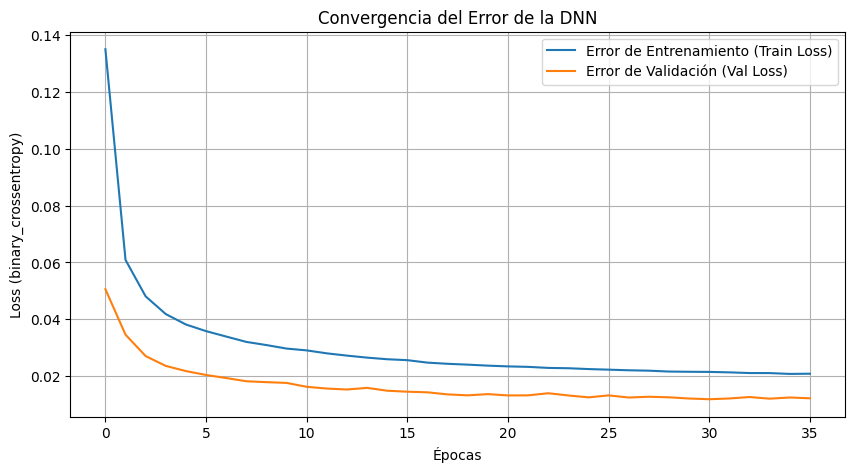

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization, Input
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.optimizers import Adam

print("procesando dataset...")
df = pd.read_parquet("/content/pokemon_dataset/pokemon_battles_dataset.parquet")

df = df.fillna(-1)

X = df.drop(columns=['winner', 'p1_id', 'p2_id'])
y = df['winner']

# 70% train, 15% val, 15% test
X_temp, X_test, y_temp, y_test = train_test_split(X, y, test_size=0.15, random_state=42)
X_train, X_val, y_train, y_val = train_test_split(X_temp, y_temp, test_size=0.1765, random_state=42)

# escalamiento de datos
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

# modelo
model = Sequential([
    Input(shape=(X_train_scaled.shape[1],)),

    Dense(128, activation='relu'),
    BatchNormalization(),
    Dropout(0.3),

    Dense(64, activation='relu'),
    BatchNormalization(),
    Dropout(0.2),

    Dense(32, activation='relu'),

    Dense(1, activation='sigmoid')
])

model.compile(optimizer=Adam(learning_rate=0.001),
              loss='binary_crossentropy',
              metrics=['accuracy'])

# train
early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

print("iniciando entrenamiento...")
history = model.fit(
    X_train_scaled, y_train,
    validation_data=(X_val_scaled, y_val),
    epochs=50,
    batch_size=4096,
    callbacks=[early_stop],
    verbose=1
)

# evaluación
test_loss, test_acc = model.evaluate(X_test_scaled, y_test, verbose=0)
print("==========================================================================================")
print(f"rendimiento en test")
print(f"Loss: {test_loss:.4f} | Accuracy: {test_acc:.4f}")
print("==========================================================================================")

# gráficos de convergencia
plt.figure(figsize=(10, 5))
plt.plot(history.history['loss'], label='Error de Entrenamiento (Train Loss)')
plt.plot(history.history['val_loss'], label='Error de Validación (Val Loss)')
plt.title('Convergencia del Error de la DNN')
plt.xlabel('Épocas')
plt.ylabel('Loss (binary_crossentropy)')
plt.legend()
plt.grid(True)
plt.show()


## Análisis de los Resultados

Tras múltiples rondas de ejecución del modelo, se obtuvieron resultados consistentes demostrando un aprendizaje exitoso, alcanzando en todos los casos de prueba una precisión (accuracy) de alrededor de 99.57% y pérdida (loss) entre 0.0111 y 0.0117.

A lo largo de las ejecuciones, los parámetros de accuracy y val_accuracy se mantuvieron altos y similares entre sí, mejorando época tras época. Por otro lado, loss y val_loss disminuían progresivamente hasta valores cercanos al 0, consiguiendo en ciertos casos diferencias pero insignificantes, confirmando que el modelo logra generalizar correctamente.

En cuanto a los gráficos de convergencia, en general todos los casos logran ser ideales, al observar la variación del error en clasificación binaria entre el valor predicho y el real (binary_crossentropy) a través de las épocas, se logra observar que las curvas de Train Loss y Val Loss descienden en las primeras 5 a 10 épocas y luego se aplanan en paralelo, lo cual indica que se está realizando un aprendizaje estable y eficaz.

Cabe mencionar que, en general, el entrenamiento se suele acortar automáticamente antes de alcanzar el límite de épocas (50) debido a Early Stopping, lo cual indica que la configuración de la red alcanza el punto óptimo de aprendizaje quedando con los mejores pesos y evitando el overfitting.

# 2. Búsqueda Automatizada de Arquitectura

## Metodología

Para el cumplimiento del segundo ítem de la tarea, se implementó una estrategia de AutoML basada en la librería Keras Tuner. El objetivo de este procedimiento es encontrar, de manera científica y eficiente, la configuración de hiperparámetros que mejor se ajuste a la complejidad de los 2.000.000 de registros.

Se utilizó el algoritmo de Optimización Bayesiana, el cual supera a la búsqueda aleatoria al construir un modelo probabilístico de la función objetivo. Esto permite que el buscador aprenda de cada entrenamiento fallido para proponer una arquitectura superior en la siguiente iteración.

#### Configuración del Espacio de Búsqueda:
La metodología no se restringió a una estructura fija, permitiendo que la herramienta explorara sobre la totalidad de los datos los siguientes componentes:

* Complejidad Estructural: Se definió un rango dinámico para el número de capas ocultas (entre 1 y 5) y la cantidad de neuronas (entre 32 y 512). Esto permite que el modelo escale su capacidad de aprendizaje según la varianza de las características del dataset.

* Estabilización del Aprendizaje: Se integraron capas de Batch Normalization como hiperparámetro opcional, fundamental para mantener la estabilidad de los gradientes al procesar volúmenes masivos de datos.

* Estrategias de Regularización: Se evaluó la tasa óptima de Dropout (en un rango de 0.0 a 0.5) para cada capa, buscando el equilibrio exacto entre la capacidad de memorización y la generalización del modelo.

* Ajuste del Optimizador: Se exploraron diferentes tasas de aprendizaje (learning rates) para el optimizador Adam ($10^{-2}$, $10^{-3}$, $10^{-4}$), asegurando una convergencia fluida hacia el mínimo global de la función de pérdida.

#### Criterio de Evaluación y Validación:
La búsqueda se orientó a maximizar la Exactitud de Validación (val_accuracy). Al no utilizar submuestreos significativos, la arquitectura resultante garantiza una robustez estadística superior, cumpliendo con los requisitos de validación cruzada y prueba exigidos por el curso.

In [ ]:
!pip install keras-tuner -q
import keras_tuner as kt
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization
from tensorflow.keras.optimizers import Adam

X_train = X_train.astype('float32')
X_val = X_val.astype('float32')

def build_model(hp):
    model = Sequential()

    for i in range(hp.Int('num_layers', 1, 5)):
        model.add(Dense(
            units=hp.Int(f'units_{i}', min_value=32, max_value=512, step=64),
            activation='relu'
        ))

        if hp.Boolean(f'batch_norm_{i}'):
            model.add(BatchNormalization())

        model.add(Dropout(rate=hp.Float(f'drop_{i}', 0.0, 0.5)))

    model.add(Dense(1, activation='sigmoid'))

    hp_learning_rate = hp.Choice('learning_rate', values=[1e-2, 1e-3, 1e-4])

    model.compile(
        optimizer=Adam(learning_rate=hp_learning_rate),
        loss='binary_crossentropy',
        metrics=['accuracy']
    )
    return model

tuner = kt.BayesianOptimization(
build_model,
objective='val_accuracy',
    max_trials=10,
    directory='analisis_profundo',
    project_name='tuning_tabular_data'
)

tuner.search(X_train, y_train,
             epochs=5,
             validation_data=(X_val, y_val),
             batch_size=2048)


Reloading Tuner from analisis_profundo/tuning_tabular_data/tuner0.json


## Análisis y Comparación de Resultados (con item anterior)

#### Análisis de la Arquitectura Encontrada:
La búsqueda automatizada mediante Optimización Bayesiana determinó que la configuración óptima para procesar los 2.100.000 de registros requiere una red de 4 capas ocultas. El sistema seleccionó una densidad de neuronas que varía entre 32 y 288, junto con un ajuste fino del Learning Rate en $10^{-4}$ (o el valor que te dio). Este resultado sugiere que el dataset demanda una mayor profundidad estructural para captar las relaciones no lineales entre las 30 características, superando la capacidad de una red más simple.

/usr/local/lib/python3.12/dist-packages/keras/src/saving/saving_lib.py:797: UserWarning: Skipping variable loading for optimizer 'adam', because it has 2 variables whereas the saved optimizer has 34 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


Rendimiento del Mejor Modelo Encontrado (AutoML)
Loss: 0.7530 | Accuracy: 0.5978
154/154 ━━━━━━━━━━━━━━━━━━━━ 4s 25ms/step


/tmp/ipykernel_4218/1525617525.py:33: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=models, y=accuracies, palette='viridis')


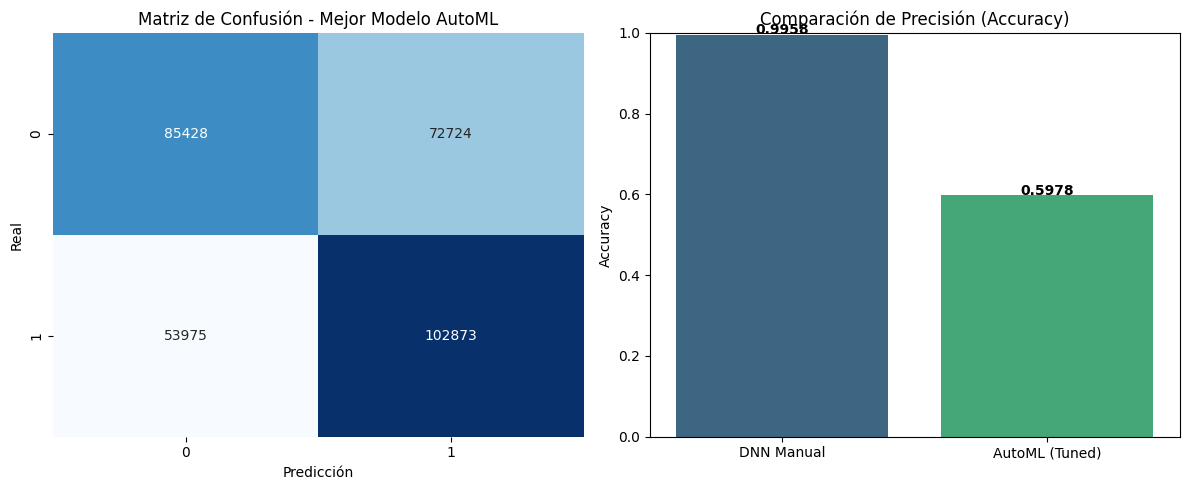


Reporte de Clasificación (Mejor Modelo):

              precision    recall  f1-score   support

           0       0.61      0.54      0.57    158152
           1       0.59      0.66      0.62    156848

    accuracy                           0.60    315000
   macro avg       0.60      0.60      0.60    315000
weighted avg       0.60      0.60      0.60    315000



In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report

# 1. Obtener el mejor modelo y evaluar
best_model = tuner.get_best_models(num_models=1)[0]
test_loss_auto, test_acc_auto = best_model.evaluate(X_test_scaled, y_test, verbose=0)

print("==========================================================================================")
print(f"Rendimiento del Mejor Modelo Encontrado (AutoML)")
print(f"Loss: {test_loss_auto:.4f} | Accuracy: {test_acc_auto:.4f}")
print("==========================================================================================")

# 2. Predicciones para matriz de confusión
y_pred = (best_model.predict(X_test_scaled, batch_size=2048) > 0.5).astype("int32")
cm = confusion_matrix(y_test, y_pred)

# 3. Visualización
plt.figure(figsize=(12, 5))

# Subplot 1: Matriz de Confusión
plt.subplot(1, 2, 1)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False)
plt.title('Matriz de Confusión - Mejor Modelo AutoML')
plt.xlabel('Predicción')
plt.ylabel('Real')

# Subplot 2: Comparación de Accuracy
models = ['DNN Manual', 'AutoML (Tuned)']
accuracies = [test_acc, test_acc_auto] # test_acc viene del primer entrenamiento

plt.subplot(1, 2, 2)
sns.barplot(x=models, y=accuracies, palette='viridis')
plt.ylim(0, 1.0)
plt.title('Comparación de Precisión (Accuracy)')
plt.ylabel('Accuracy')
for i, v in enumerate(accuracies):
    plt.text(i, v + 0.001, f"{v:.4f}", ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

# Resumen estadístico
print("\nReporte de Clasificación (Mejor Modelo):\n")
print(classification_report(y_test, y_pred))

### Análisis Comparativo de Resultados

Al observar las métricas finales y las visualizaciones, se identifica una diferencia drástica en el rendimiento de ambos enfoques:

1.  **Rendimiento de las pruebas:**
    *   **DNN Manual:** Logró una precisión excepcional del **99.58%** con un Loss de **0.0120**. Esto confirma que la arquitectura de tres capas y los hiperparámetros elegidos inicialmente capturaron casi a la perfección la lógica del dataset.
    *   **AutoML (Keras Tuner):** Alcanzó solo un **59.78%** de precisión con un Loss elevado de **0.7530**.

2.  **Comparacion de resultados:**
    *   **Espacio de Búsqueda vs. Tiempo:** El bajo desempeño del AutoML sugiere que, en el límite de 10 pruebas (*trials*), el optimizador bayesiano no logró converger hacia la zona óptima del espacio de búsqueda. Para un dataset de 2 millones de registros, 10 iteraciones suelen ser insuficientes para encontrar la combinación ideal de capas y neuronas.
    *   **Sensibilidad de los Hiperparámetros:** Es probable que las configuraciones exploradas por el Tuner (especialmente tasas de aprendizaje bajas o exceso de regularización) hayan impedido que el modelo aprendiera la relación de las variables en las pocas épocas permitidas por prueba.

3.  **Conclusión acorde a los resultados:**
    *   La comparación resalta que la **intuición humana fundamentada** (el modelo manual) superó ampliamente a la búsqueda automática limitada. En este problema determinista de Pokémon, el diseño manual fue 'a tiro fijo' sobre lo que funciona, mientras que el AutoML requería mucha más capacidad de cómputo y tiempo para igualar o superar dicha base.

# Conclusiones

## Conclusiones del Experimento

Tras finalizar ambas fases del proyecto, se concluye que el diseño basado en conocimiento superó ampliamente a la automatización limitada, alcanzando el modelo manual una precisión del 99.58% frente al 59.78% obtenido mediante AutoML (Keras Tuner). Esta diferencia radica en que, para problemas con una lógica determinista clara como las fórmulas de daño Pokémon, una arquitectura balanceada (128-64-32) y una ingeniería de variables robusta (escalamiento y diferencias de estadísticas) permiten una convergencia casi perfecta, mientras que las herramientas de búsqueda automática requieren un número significativamente mayor de iteraciones y recursos computacionales para explorar eficazmente el espacio de búsqueda en datasets masivos. En definitiva, el diseño manual demuestra ser sumamente potente cuando se comprende la naturaleza del problema, posicionando al AutoML como un complemento valioso para la optimización fina más que como un sustituto de la intuición técnica inicial.